# 📈 Ultimate Strategy Performance Dashboard
### Global MSCI & S&P 500 Strategy Analysis (1970 - Present)

This notebook provides a multi-dimensional risk/return analysis of your hybrid and benchmark strategies.

---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import glob
import os
from datetime import datetime
from IPython.display import display

# --- 1. CORE CONFIGURATION & INTERACTIVE LOAD ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.labelweight'] = 'bold'

STRAT_LABELS = {
    'S1': 'Hybrid: 70% SPY / 15% UPRO / 15% Gold',
    'S2': 'Dull: 100% S&P 500',
    'S3': 'Hybrid: 70% MSCI World / 15% UPRO / 15% Gold',
    'S4': 'Dull: 100% MSCI World'
}

all_runs = glob.glob('data/BT_*_*/rolling_*_results.csv')
all_runs.sort(key=os.path.getmtime, reverse=True)

if not all_runs:
    print("❌ No results found.")
else:
    print("📋 Available Backtest Runs (Newest First):")
    for i, run in enumerate(all_runs):
        print(f"[{i}] {os.path.dirname(run)}")
    
    try:
        idx = int(input("\nSelect run index to load: ") or 0)
        selected_run = all_runs[idx]
    except:
        selected_run = all_runs[0]

    latest_folder = os.path.dirname(selected_run)
    df = pd.read_csv(selected_run, index_col=0, parse_dates=True)
    cagr_cols = [c for c in df.columns if 'CAGR' in c]
    mdd_cols = [c for c in df.columns if 'MDD' in c]
    
    print(f"\n✅ ACTIVATED: {latest_folder}")

📋 Available Backtest Runs (Newest First):
[0] BT_20y_1987-01-01_to_2024_20260429_211958
[1] BT_25y_1970-01-01_to_2024_20260429_190432
[2] BT_35y_1970-01-01_to_2024_20260429_190222
[3] BT_20y_1970-01-01_to_2024_20260429_184155
[4] BT_20y_1970-01-01_to_2024_20260429_184005
[5] BT_10y_1990-01-01_to_2024_20260428_220044
[6] BT_10y_1990-01-01_to_2024_20260428_215539
[7] BT_20y_1990-01-01_to_2024_20260428_215328
[8] BT_20y_1980-01-01_to_2024_20260421_180652
[9] BT_20y_1950-01-01_to_2024_20260421_174745
[10] BT_20y_1950-01-01_to_2024_20260421_174502
[11] BT_40y_1950-01-01_to_2024_20260421_174131
[12] BT_40y_1930-01-01_to_2024_20260421_173824
[13] BT_40y_1930-01-01_to_2024_20260421_173211
[14] BT_40y_1925-01-01_to_2024_20260421_172241
[15] BT_10y_1965-01-01_to_2024_20260420_211213
[16] BT_40y_1965-01-01_to_2024_20260420_211100
[17] BT_20y_1965-01-01_to_2024_20260420_210502
[18] BT_20y_1930-01-01_to_2024_20260420_210122
[19] BT_20y_2000-01-01_to_2024_20260420_205551
[20] BT_20y_2000-01-01_to_20

## 📊 1. Core Summary Statistics
Baseline performance metrics across all rolling windows.

In [ ]:
stats = []
for col in cagr_cols:
    code = col.replace('_CAGR', '')
    label = STRAT_LABELS.get(code, code)
    mdd_col = f"{code}_MDD"
    stats.append({
        'Strategy': label,
        'Median CAGR (%)': round(df[col].median() * 100, 2),
        '25th Percentile (%)': round(df[col].quantile(0.25) * 100, 2),
        'Median MDD (%)': round(df[mdd_col].median() * 100, 2) if mdd_col in df.columns else 'N/A'
    })
stats_df = pd.DataFrame(stats).set_index('Strategy')
display(stats_df)

,Median CAGR (%),25th Percentile (%),Median MDD (%)
Strategy,,,
Hybrid: 70% SPY / 15% UPRO / 15% Gold,8.99,7.76,-59.58
Dull: 100% S&P 500,8.09,7.19,-55.86
Hybrid: 70% MSCI World / 15% UPRO / 15% Gold,8.90,7.44,-59.38
Dull: 100% MSCI World,7.85,6.54,-55.55


## 📉 2. Performance Distributions (Density & Quartiles)

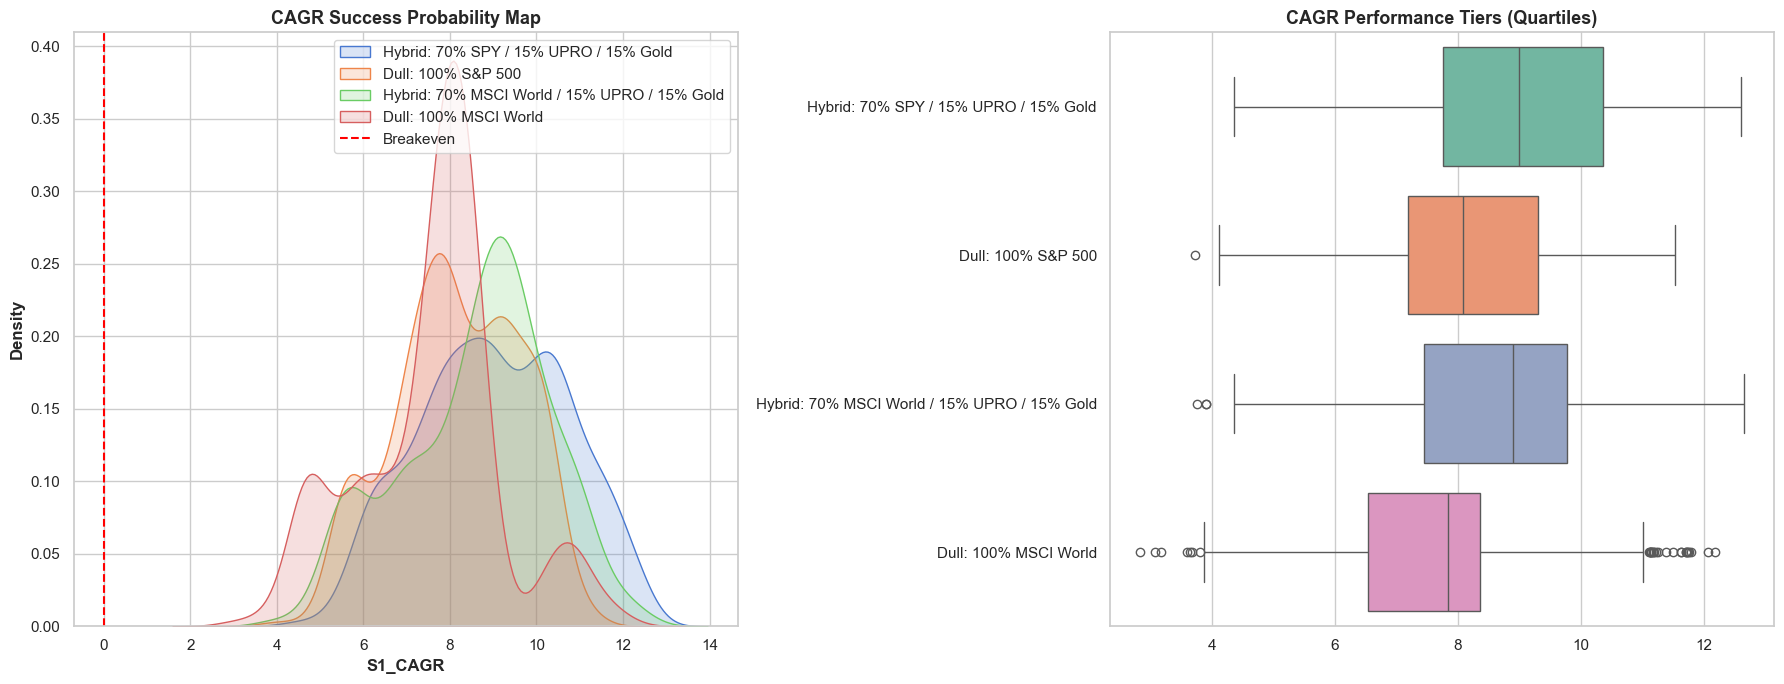

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# KDE Probability Density
for col in cagr_cols:
    label = STRAT_LABELS.get(col.replace('_CAGR',''), col.replace('_CAGR',''))
    sns.kdeplot(df[col] * 100, label=label, fill=True, alpha=0.2, ax=ax[0])
ax[0].axvline(0, color='red', linestyle='--', label='Breakeven')
ax[0].set_title("CAGR Success Probability Map", fontsize=13, fontweight='bold')
ax[0].legend()

# Boxplot Quartiles
plot_df = df[cagr_cols].copy() * 100
plot_df.columns = [STRAT_LABELS.get(c.replace('_CAGR',''), c.replace('_CAGR','')) for c in plot_df.columns]
sns.boxplot(data=plot_df, orient="h", palette="Set2", ax=ax[1])
ax[1].set_title("CAGR Performance Tiers (Quartiles)", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 📅 3. Rolling CAGR Timeline
Performance through historical cycles (e.g., 70s Inflation, 00s Dotcom).

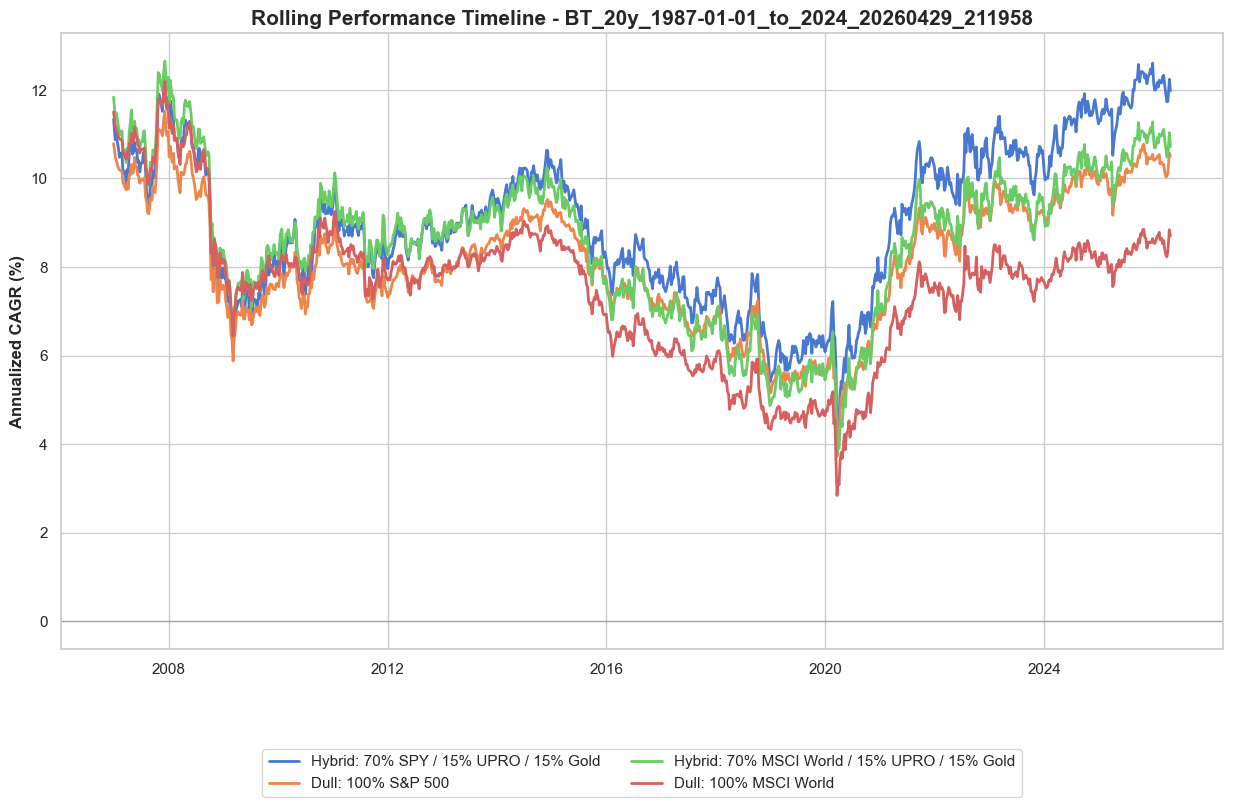

In [ ]:
plt.figure(figsize=(15, 8))
for col in cagr_cols:
    label = STRAT_LABELS.get(col.replace('_CAGR',''), col.replace('_CAGR',''))
    plt.plot(df.index, df[col] * 100, label=label, linewidth=2)

plt.axhline(0, color='black', alpha=0.2, lw=1)
plt.title(f"Rolling Performance Timeline - {latest_folder}", fontsize=15, fontweight='bold')
plt.ylabel("Annualized CAGR (%)")
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2)
plt.show()

## 🛡️ 4. Risk Profile: CDF & Drawdown Timeline

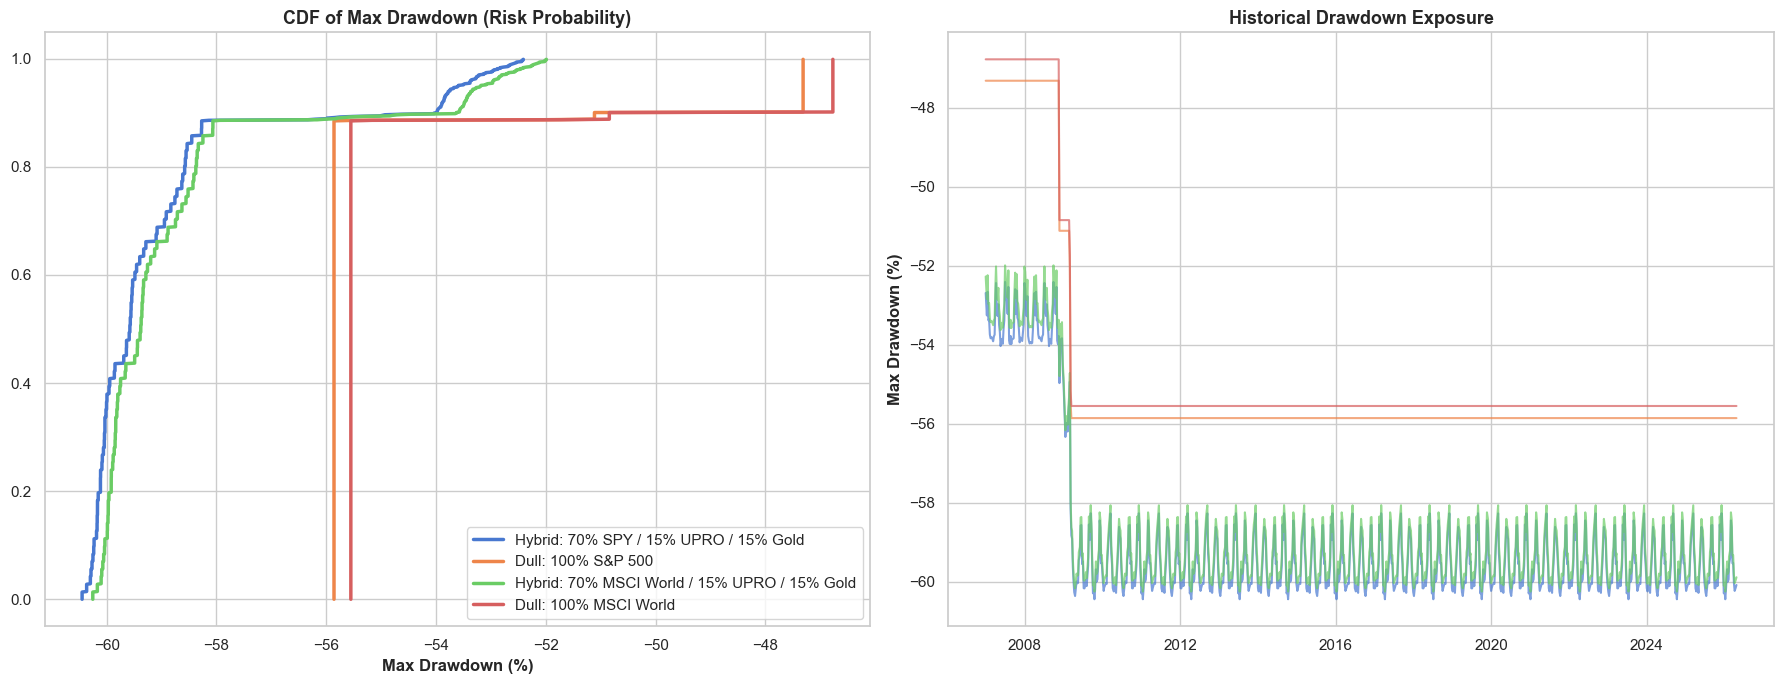

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# CDF Curve
for col in mdd_cols:
    label = STRAT_LABELS.get(col.replace('_MDD',''), col.replace('_MDD',''))
    sorted_mdd = np.sort(df[col] * 100)
    y = np.arange(len(sorted_mdd)) / float(len(sorted_mdd))
    ax[0].plot(sorted_mdd, y, label=label, linewidth=2.5)
ax[0].set_title("CDF of Max Drawdown (Risk Probability)", fontsize=13, fontweight='bold')
ax[0].set_xlabel("Max Drawdown (%)")
ax[0].legend()

# MDD Timeline
for col in mdd_cols:
    label = STRAT_LABELS.get(col.replace('_MDD',''), col.replace('_MDD',''))
    ax[1].plot(df.index, df[col] * 100, label=label, alpha=0.7)
ax[1].set_title("Historical Drawdown Exposure", fontsize=13, fontweight='bold')
ax[1].set_ylabel("Max Drawdown (%)")

plt.tight_layout()
plt.show()